# CIC-MalMem-2022 Revalidation — 01 Data Audit and Locked Split

**Team B — Generative Augmentation and Quantum Crossover**  
**Author:** Marco Matya  
**Protocol version:** Revalidation v2

This notebook establishes the immutable data contract for every subsequent
SMOTE, ADASYN, CTGAN, QGAN, classical-classifier, and quantum hand-off run.
It performs no augmentation and trains no predictive model.

## Research controls

1. Verify the exact input file by SHA-256, shape, schema, duplicate count,
   and clean class counts.
2. Normalize the four-class target without confusing the binary `Class`
   field with the malware-family target.
3. Remove only exact duplicate rows and retain stable row identifiers.
4. Create one stratified 70/15/15 split with seed 42.
5. Fit imputation, constant-feature removal, and scaling on the training
   partition only.
6. Save machine-readable manifests so every later notebook can prove that
   it used the same rows and preprocessing contract.


## 0. Expected canonical dataset

The prior project runs identified the canonical raw file with:

- 58,596 raw rows;
- 534 exact full-record duplicates (including sample identifiers);
- 58,062 clean rows;
- clean classes: Benign 29,231, Ransomware 9,529, Spyware 9,815,
  Trojan 9,487;
- SHA-256 `cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a`.


In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import shutil
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("default")

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.0
pandas: 2.3.3
NumPy: 2.5.2
scikit-learn: 1.7.2


## 1. Configuration

In [2]:
def resolve_project_root(project_name: str = "Marco_Revalidation_v2") -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        nested = candidate / project_name
        if nested.exists():
            return nested.resolve()
    return (cwd / project_name).resolve()


# --------------------------- USER CONFIGURATION ---------------------------
PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "MalMem2022.csv"
PROTOCOL_DIR = PROJECT_ROOT / "00_protocol"
OUTPUT_DIR = PROJECT_ROOT / "01_data_contract"

SEED = 42
TEST_FRACTION = 0.15
VALIDATION_FRACTION = 0.15

ENFORCE_CANONICAL_SHA256 = True
ALLOW_PRECLEANED_INPUT = False
ALLOW_NONSTANDARD_DATASET = False
# -------------------------------------------------------------------------

EXPECTED_CANONICAL_SHA256 = (
    "cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a"
)
EXPECTED_RAW_ROWS = 58_596
EXPECTED_DUPLICATES = 534
EXPECTED_CLEAN_ROWS = 58_062
EXPECTED_CLEAN_CLASS_COUNTS = {
    "Benign": 29_231,
    "Ransomware": 9_529,
    "Spyware": 9_815,
    "Trojan": 9_487,
}
CLASS_ORDER = ["Benign", "Ransomware", "Spyware", "Trojan"]
TARGET = "Label"

PROTOCOL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Input:", DATA_PATH.resolve())
print("Outputs:", OUTPUT_DIR.resolve())


Project root: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2
Input: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2\data\MalMem2022.csv
Outputs: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2\01_data_contract


## 2. Reproducibility utilities


In [3]:
def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def normalize_family(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    lower = text.lower()
    if lower == "benign":
        return "Benign"
    for family in ("Ransomware", "Spyware", "Trojan"):
        if lower.startswith(family.lower()):
            return family
    return np.nan


def target_column_diagnostics(frame: pd.DataFrame) -> pd.DataFrame:
    preferred = [
        "Category", "category", "Label", "label", "Family", "family",
        "Class", "class",
    ]
    rows = []
    for column in preferred:
        if column not in frame.columns:
            continue
        mapped = frame[column].map(normalize_family)
        non_null = int(frame[column].notna().sum())
        mapped_count = int(mapped.notna().sum())
        rows.append({
            "column": column,
            "non_null": non_null,
            "mapped_to_four_classes": mapped_count,
            "mapped_fraction": mapped_count / max(non_null, 1),
            "mapped_classes": sorted(mapped.dropna().unique().tolist()),
            "raw_unique_count": int(frame[column].nunique(dropna=True)),
        })
    return pd.DataFrame(rows)


def select_multiclass_target(frame: pd.DataFrame):
    diagnostics = target_column_diagnostics(frame)
    if diagnostics.empty:
        raise KeyError(
            "No plausible target column found. Expected Category, Label, "
            "Family, or Class."
        )
    eligible = diagnostics[
        (diagnostics["mapped_fraction"] == 1.0)
        & diagnostics["mapped_classes"].map(lambda x: set(x) == set(CLASS_ORDER))
    ]
    if eligible.empty:
        raise ValueError(
            "No column maps completely to all four required classes.\n"
            + diagnostics.to_string(index=False)
        )
    priority = {name: rank for rank, name in enumerate(
        ["Category", "category", "Label", "label", "Family", "family", "Class", "class"]
    )}
    selected = min(eligible["column"], key=lambda name: priority[name])
    return selected, diagnostics


def stable_row_ids(frame: pd.DataFrame) -> pd.Series:
    # Deterministic within the recorded pandas version. Exact duplicates must
    # already be removed; collisions are checked immediately afterwards.
    hashed = pd.util.hash_pandas_object(frame, index=False).astype("uint64")
    return hashed.map(lambda value: f"row_{int(value):016x}")


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if pd.isna(value):
        return None
    return value


## 3. Load and fingerprint the raw file

This is the first hard gate. A small, truncated, mostly benign, or processed
derivative must not proceed into model training under the canonical name.


In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}\n"
        "Place the official file beside this notebook or update DATA_PATH."
    )

actual_sha256 = sha256_file(DATA_PATH)
raw = pd.read_csv(DATA_PATH, low_memory=False)
raw.columns = raw.columns.astype(str).str.strip()

if raw.columns.duplicated().any():
    duplicated_names = raw.columns[raw.columns.duplicated()].tolist()
    raise ValueError(f"Duplicated column names after stripping: {duplicated_names}")

raw_shape = tuple(raw.shape)

raw_full_duplicate_count = int(raw.duplicated(keep="first").sum())

print("SHA-256:", actual_sha256)
print("Raw shape:", raw_shape)
print("Exact full-row duplicates (metadata included):", raw_full_duplicate_count)
print("Total missing cells:", int(raw.isna().sum().sum()))

if ENFORCE_CANONICAL_SHA256 and actual_sha256 != EXPECTED_CANONICAL_SHA256:
    raise AssertionError(
        "DATASET HASH MISMATCH.\n"
        f"Expected: {EXPECTED_CANONICAL_SHA256}\n"
        f"Observed: {actual_sha256}\n"
        "Do not continue until you identify the exact source/version. If this "
        "is an approved alternative, disable the hash gate and preserve this "
        "observed hash in the new manifest."
    )


SHA-256: cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a
Raw shape: (58596, 58)
Exact full-row duplicates (metadata included): 534
Total missing cells: 0


## 4. Audit the target and data quality


In [ ]:
source_target, target_diagnostics = select_multiclass_target(raw)
display(target_diagnostics)
print("Selected multiclass source column:", source_target)

audit = raw.copy()
audit[TARGET] = audit[source_target].map(normalize_family)

if audit[TARGET].isna().any():
    examples = audit.loc[audit[TARGET].isna(), source_target].value_counts(dropna=False).head(20)
    raise ValueError(
        "Unmapped multiclass target values were found:\n" + examples.to_string()
    )

metadata_names_casefold = {
    "category", "label", "family", "class",
    "filename", "file_name", "file", "filepath", "file_path",
    "sha256", "sha1", "md5", "hash", "sample_id", "id", "index",
}
metadata_columns = {
    column for column in audit.columns
    if column.strip().casefold() in metadata_names_casefold
    or column.strip().casefold().startswith("unnamed:")
}
candidate_features = [
    column for column in audit.columns if column not in metadata_columns
]
if not candidate_features:
    raise ValueError("No candidate feature columns remain after excluding metadata.")

numeric_features = audit[candidate_features].apply(pd.to_numeric, errors="coerce")
coercion_created_missing = (
    numeric_features.isna().sum() - audit[candidate_features].isna().sum()
).clip(lower=0)
bad_coercions = coercion_created_missing[coercion_created_missing > 0].sort_values(ascending=False)
if not bad_coercions.empty:
    raise TypeError(
        "Some candidate features contain non-numeric values that would be lost:\n"
        + bad_coercions.to_string()
    )

inf_mask = np.isinf(numeric_features.to_numpy(dtype=float))
nonfinite_count = int(inf_mask.sum())
numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan)
audit[candidate_features] = numeric_features

model_duplicate_columns = [TARGET, *candidate_features]
model_duplicate_count = int(
    audit.duplicated(subset=model_duplicate_columns, keep="first").sum()
)

quality_table = pd.DataFrame({
    "dtype_after_numeric_check": audit[candidate_features].dtypes.astype(str),
    "missing_count": audit[candidate_features].isna().sum(),
    "missing_fraction": audit[candidate_features].isna().mean(),
    "unique_non_null": audit[candidate_features].nunique(dropna=True),
}).sort_values(["missing_count", "unique_non_null"], ascending=[False, True])

print("Feature candidates:", len(candidate_features))
print("Excluded metadata columns:", sorted(metadata_columns))
print("Exact modeling-row duplicates:", model_duplicate_count)
print("Infinite cells converted to missing:", nonfinite_count)
display(quality_table.head(20))


,column,non_null,mapped_to_four_classes,mapped_fraction,mapped_classes,raw_unique_count
0,Category,58596,58596,1.0,"[Benign, Ransomware, Spyware, Trojan]",16
1,Class,58596,29298,0.5,[Benign],2


Selected multiclass source column: Category
Feature candidates: 55
Excluded metadata columns: ['Category', 'Class', 'Filename', 'Label']
Exact modeling-row duplicates: 559
Infinite cells converted to missing: 0


,dtype_after_numeric_check,missing_count,missing_fraction,unique_non_null
pslist.nprocs64bit,int64,0,0.0,1
handles.nport,int64,0,0.0,1
svcscan.interactive_process_services,int64,0,0.0,1
psxview.not_in_eprocess_pool,int64,0,0.0,2
callbacks.nanonymous,int64,0,0.0,2
callbacks.ngeneric,int64,0,0.0,2
modules.nmodules,int64,0,0.0,3
svcscan.fs_drivers,int64,0,0.0,10
callbacks.ncallbacks,int64,0,0.0,13
svcscan.process_services,int64,0,0.0,14


## 5. Exact deduplication and canonical-contract gate


In [ ]:
if raw_shape[0] == EXPECTED_CLEAN_ROWS and raw_full_duplicate_count == 0:
    if not ALLOW_PRECLEANED_INPUT:
        raise AssertionError(
            "The input appears to be already cleaned (58,062 rows and no exact "
            "duplicates). Set ALLOW_PRECLEANED_INPUT=True only after documenting "
            "its provenance; otherwise use the canonical raw file."
        )
    clean = audit.reset_index(drop=True).copy()
    input_state = "precleaned_approved"
else:
    clean = audit.drop_duplicates(keep="first").reset_index(drop=True).copy()
    input_state = "raw_deduplicated_in_notebook"

clean_modeling_shape = (len(clean), len(model_duplicate_columns))
feature_equivalent_extra_count = model_duplicate_count - raw_full_duplicate_count
clean_class_counts = (
    clean[TARGET].value_counts().reindex(CLASS_ORDER, fill_value=0).astype(int).to_dict()
)

contract_observed = {
    "raw_rows": raw_shape[0],
    "raw_columns": raw_shape[1],
    "full_raw_duplicates_with_metadata": raw_full_duplicate_count,
    "modeling_duplicates_ignoring_identifiers": model_duplicate_count,
    "additional_feature_equivalent_distinct_files": feature_equivalent_extra_count,
    "clean_rows": len(clean),
    "clean_class_counts": clean_class_counts,
}
display(pd.Series(contract_observed, name="observed"))

contract_problems = []
if input_state == "raw_deduplicated_in_notebook":
    if raw_shape[0] != EXPECTED_RAW_ROWS:
        contract_problems.append(f"raw rows: expected {EXPECTED_RAW_ROWS}, observed {raw_shape[0]}")
    if raw_full_duplicate_count != EXPECTED_DUPLICATES:
        contract_problems.append(
            f"full-record duplicates: expected {EXPECTED_DUPLICATES}, "
            f"observed {raw_full_duplicate_count}"
        )
if len(clean) != EXPECTED_CLEAN_ROWS:
    contract_problems.append(f"clean rows: expected {EXPECTED_CLEAN_ROWS}, observed {len(clean)}")
if clean_class_counts != EXPECTED_CLEAN_CLASS_COUNTS:
    contract_problems.append(
        f"class counts: expected {EXPECTED_CLEAN_CLASS_COUNTS}, observed {clean_class_counts}"
    )

if contract_problems and not ALLOW_NONSTANDARD_DATASET:
    raise AssertionError(
        "CANONICAL DATA CONTRACT FAILED:\n- " + "\n- ".join(contract_problems)
        + "\nDo not train models until the discrepancy is resolved."
    )

clean["row_id"] = stable_row_ids(clean.drop(columns=["row_id"], errors="ignore"))
if clean["row_id"].duplicated().any():
    raise RuntimeError("Stable row-ID collision detected; replace the row-ID method.")

clean["model_group_id"] = stable_row_ids(clean[model_duplicate_columns])

print("Canonical contract:", "PASSED" if not contract_problems else "OVERRIDDEN WITH WARNING")
print("Clean shape:", clean.shape)
display(clean[TARGET].value_counts().reindex(CLASS_ORDER).rename("count").to_frame())


raw_rows                                                                                    58596
raw_columns                                                                                    58
full_raw_duplicates_with_metadata                                                             534
modeling_duplicates_ignoring_identifiers                                                      559
additional_feature_equivalent_distinct_files                                                   25
clean_rows                                                                                  58062
clean_class_counts                              {'Benign': 29231, 'Ransomware': 9529, 'Spyware...
Name: observed, dtype: object

Canonical contract: PASSED
Clean shape: (58062, 61)


,count
Label,
Benign,29231
Ransomware,9529
Spyware,9815
Trojan,9487


## 6. Locked 70/15/15 stratified split


In [7]:
all_positions = np.arange(len(clean))
train_val_pos, test_pos = train_test_split(
    all_positions,
    test_size=TEST_FRACTION,
    stratify=clean[TARGET],
    random_state=SEED,
)
relative_validation_fraction = VALIDATION_FRACTION / (1.0 - TEST_FRACTION)
train_pos, validation_pos = train_test_split(
    train_val_pos,
    test_size=relative_validation_fraction,
    stratify=clean.iloc[train_val_pos][TARGET],
    random_state=SEED,
)

partition_by_position = np.empty(len(clean), dtype=object)
partition_by_position[train_pos] = "train"
partition_by_position[validation_pos] = "validation"
partition_by_position[test_pos] = "test"
clean["partition"] = partition_by_position

split_manifest = clean[["row_id", "model_group_id", TARGET, "partition"]].copy()
split_manifest.insert(0, "clean_position", np.arange(len(clean)))

partition_sets = {
    name: set(split_manifest.loc[split_manifest["partition"].eq(name), "row_id"])
    for name in ["train", "validation", "test"]
}
assert partition_sets["train"].isdisjoint(partition_sets["validation"])
assert partition_sets["train"].isdisjoint(partition_sets["test"])
assert partition_sets["validation"].isdisjoint(partition_sets["test"])
assert set.union(*partition_sets.values()) == set(clean["row_id"])

split_counts = pd.crosstab(
    split_manifest["partition"], split_manifest[TARGET]
).reindex(index=["train", "validation", "test"], columns=CLASS_ORDER, fill_value=0)
split_counts["Total"] = split_counts.sum(axis=1)
display(split_counts)

expected_sizes = {"train": 40_642, "validation": 8_710, "test": 8_710}
observed_sizes = split_manifest["partition"].value_counts().to_dict()
if not ALLOW_NONSTANDARD_DATASET and observed_sizes != expected_sizes:
    raise AssertionError(
        f"Split sizes differ from the canonical contract. Expected {expected_sizes}; "
        f"observed {observed_sizes}."
    )

expected_split_counts = pd.DataFrame(
    {
        "Benign": [20_461, 4_385, 4_385],
        "Ransomware": [6_670, 1_429, 1_430],
        "Spyware": [6_870, 1_473, 1_472],
        "Trojan": [6_641, 1_423, 1_423],
    },
    index=["train", "validation", "test"],
)
if not ALLOW_NONSTANDARD_DATASET:
    observed_split_counts = split_counts.drop(columns="Total").astype(int)
    if not observed_split_counts.equals(expected_split_counts):
        raise AssertionError(
            "Per-class split counts differ from the canonical seed-42 contract.\n"
            f"Expected:\n{expected_split_counts}\nObserved:\n{observed_split_counts}"
        )

# Diagnostic for identical model vectors distributed across partitions.
model_group_partition_counts = (
    split_manifest.groupby("model_group_id")["partition"].nunique()
)
cross_partition_group_ids = model_group_partition_counts[
    model_group_partition_counts > 1
].index
cross_partition_model_groups = split_manifest[
    split_manifest["model_group_id"].isin(cross_partition_group_ids)
].sort_values(["model_group_id", "partition", "row_id"])
print(
    "Feature-equivalent groups crossing partitions:",
    len(cross_partition_group_ids),
)
if len(cross_partition_group_ids):
    print(
        "Warning: retain this diagnostic and run a group-aware sensitivity "
        "analysis before the final publication claim."
    )


Label,Benign,Ransomware,Spyware,Trojan,Total
partition,,,,,
train,20461,6670,6870,6641,40642
validation,4385,1429,1473,1423,8710
test,4385,1430,1472,1423,8710


Feature-equivalent groups crossing partitions: 12


## 7. Training-only preprocessing

The reusable preprocessing contract is:

1. median imputation fitted on training rows;
2. constant-feature removal determined on the imputed training matrix;
3. standardization fitted on the retained training features.

PCA is intentionally **not** fitted here. Classical tabular models, CTGAN,
and the QGAN branch have different representation requirements. Each later
notebook must load this locked split and fit any additional representation
on training rows only.


In [8]:
feature_columns = candidate_features.copy()

train_frame = clean.loc[clean["partition"].eq("train")].copy()
validation_frame = clean.loc[clean["partition"].eq("validation")].copy()
test_frame = clean.loc[clean["partition"].eq("test")].copy()

X_train_raw = train_frame[feature_columns]
X_validation_raw = validation_frame[feature_columns]
X_test_raw = test_frame[feature_columns]

imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_raw)
X_validation_imputed = imputer.transform(X_validation_raw)
X_test_imputed = imputer.transform(X_test_raw)

train_variances = np.var(X_train_imputed, axis=0)
retained_mask = train_variances > 0.0
retained_features = np.asarray(feature_columns)[retained_mask].tolist()
constant_features = np.asarray(feature_columns)[~retained_mask].tolist()

if not retained_features:
    raise RuntimeError("Every feature is constant after training-only imputation.")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed[:, retained_mask])
X_validation_scaled = scaler.transform(X_validation_imputed[:, retained_mask])
X_test_scaled = scaler.transform(X_test_imputed[:, retained_mask])

for name, matrix in {
    "train": X_train_scaled,
    "validation": X_validation_scaled,
    "test": X_test_scaled,
}.items():
    if not np.isfinite(matrix).all():
        raise RuntimeError(f"Non-finite values remain in the {name} processed matrix.")

print("Input feature count:", len(feature_columns))
print("Retained feature count:", len(retained_features))
print("Training-constant features:", constant_features)
print("Scaled matrices:", X_train_scaled.shape, X_validation_scaled.shape, X_test_scaled.shape)


Input feature count: 55
Retained feature count: 52
Training-constant features: ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']
Scaled matrices: (40642, 52) (8710, 52) (8710, 52)


## 8. Descriptive figures

These figures diagnose the locked data contract; they are not evidence that
one augmentation method is superior.


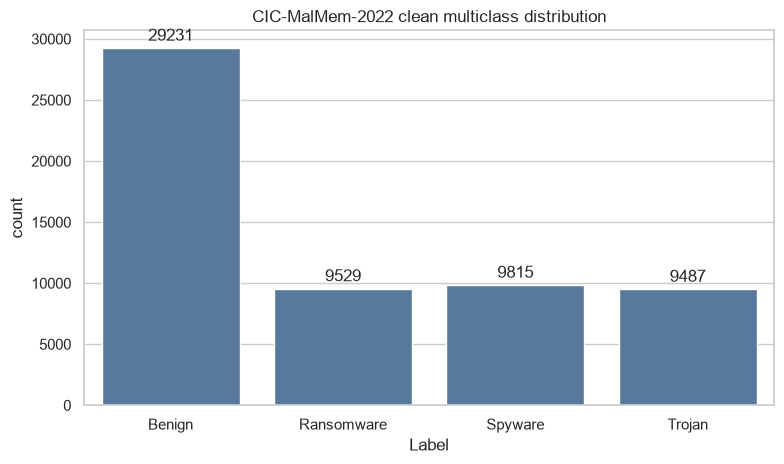

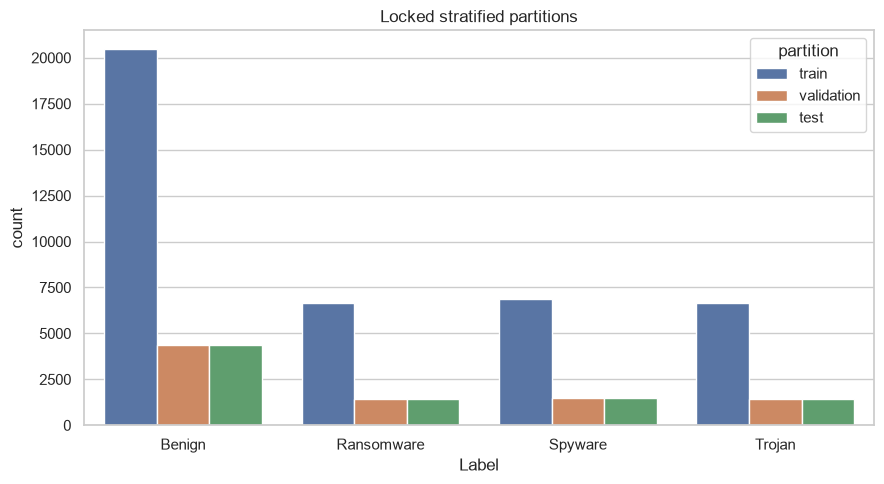

In [9]:
class_plot = (
    clean[TARGET].value_counts().reindex(CLASS_ORDER).rename_axis(TARGET).reset_index(name="count")
)
plt.figure(figsize=(8, 4.8))
ax = sns.barplot(data=class_plot, x=TARGET, y="count", color="#4C78A8")
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.title("CIC-MalMem-2022 clean multiclass distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_clean_class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

split_long = (
    split_counts.drop(columns="Total")
    .reset_index()
    .melt(id_vars="partition", var_name=TARGET, value_name="count")
)
plt.figure(figsize=(9, 5))
sns.barplot(data=split_long, x=TARGET, y="count", hue="partition")
plt.title("Locked stratified partitions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_locked_split_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Save the immutable data contract

Later notebooks should consume these artifacts instead of recreating the
split. The compressed clean CSV contains `row_id` and `partition`; the NPZ
contains the reusable scaled matrices and labels; the joblib file stores
the fitted preprocessing objects and exact feature lists.


In [10]:
created_at_utc = datetime.now(timezone.utc).isoformat()

clean_output_columns = [
    "row_id", "model_group_id", "partition", TARGET,
    *feature_columns,
]
clean_export = clean[clean_output_columns].copy()
clean_export.to_csv(
    OUTPUT_DIR / "malmem2022_clean_locked.csv.gz",
    index=False,
    compression="gzip",
)
split_manifest.to_csv(OUTPUT_DIR / "split_manifest.csv", index=False)
split_counts.to_csv(OUTPUT_DIR / "locked_split_class_counts.csv")
cross_partition_model_groups.to_csv(
    OUTPUT_DIR / "cross_partition_model_groups.csv", index=False
)
quality_table.to_csv(OUTPUT_DIR / "feature_quality_audit.csv")
target_diagnostics.to_csv(OUTPUT_DIR / "target_column_diagnostics.csv", index=False)

preprocessing_bundle = {
    "protocol_version": "revalidation_v2_data_contract_v1",
    "created_at_utc": created_at_utc,
    "seed": SEED,
    "target": TARGET,
    "class_order": CLASS_ORDER,
    "feature_columns": feature_columns,
    "retained_features": retained_features,
    "constant_features": constant_features,
    "retained_mask": retained_mask,
    "imputer": imputer,
    "scaler": scaler,
    "dataset_sha256": actual_sha256,
}
joblib.dump(preprocessing_bundle, OUTPUT_DIR / "preprocessing.joblib")

np.savez_compressed(
    OUTPUT_DIR / "locked_preprocessed_splits.npz",
    X_train=X_train_scaled.astype(np.float32),
    X_validation=X_validation_scaled.astype(np.float32),
    X_test=X_test_scaled.astype(np.float32),
    y_train=train_frame[TARGET].to_numpy(dtype=str),
    y_validation=validation_frame[TARGET].to_numpy(dtype=str),
    y_test=test_frame[TARGET].to_numpy(dtype=str),
    row_id_train=train_frame["row_id"].to_numpy(dtype=str),
    row_id_validation=validation_frame["row_id"].to_numpy(dtype=str),
    row_id_test=test_frame["row_id"].to_numpy(dtype=str),
    retained_features=np.asarray(retained_features, dtype=str),
)

dataset_manifest = {
    "protocol_version": "revalidation_v2_data_contract_v1",
    "created_at_utc": created_at_utc,
    "source_file": str(DATA_PATH.resolve()),
    "source_filename": DATA_PATH.name,
    "source_sha256": actual_sha256,
    "canonical_sha256_expected": EXPECTED_CANONICAL_SHA256,
    "canonical_hash_enforced": ENFORCE_CANONICAL_SHA256,
    "input_state": input_state,
    "raw_shape": list(raw_shape),
    "full_raw_duplicate_count_with_metadata": raw_full_duplicate_count,
    "modeling_duplicate_count_ignoring_identifiers": model_duplicate_count,
    "additional_feature_equivalent_distinct_files": feature_equivalent_extra_count,
    "cross_partition_model_group_count": int(len(cross_partition_group_ids)),
    "clean_modeling_shape": list(clean_modeling_shape),
    "clean_class_counts": clean_class_counts,
    "target_source_column": source_target,
    "target_column": TARGET,
    "class_order": CLASS_ORDER,
    "feature_count_before_train_only_filter": len(feature_columns),
    "retained_feature_count": len(retained_features),
    "retained_features": retained_features,
    "training_constant_features": constant_features,
    "nonfinite_cells_replaced_with_missing": nonfinite_count,
    "split": {
        "seed": SEED,
        "train_fraction": 1.0 - VALIDATION_FRACTION - TEST_FRACTION,
        "validation_fraction": VALIDATION_FRACTION,
        "test_fraction": TEST_FRACTION,
        "sizes": observed_sizes,
        "class_counts": split_counts.drop(columns="Total").to_dict(orient="index"),
    },
    "software": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
    "test_partition_disclosure": (
        "Fixed held-out evaluation partition reused for protocol reconciliation; "
        "it was inspected in earlier project iterations."
    ),
}
with (OUTPUT_DIR / "dataset_manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(json_safe(dataset_manifest), handle, indent=2, ensure_ascii=False)

experiment_protocol = {
    "project": "Marco_Revalidation_v2",
    "protocol_version": "revalidation_v2",
    "dataset": "CIC-MalMem-2022",
    "dataset_sha256": actual_sha256,
    "target": TARGET,
    "class_order": CLASS_ORDER,
    "split": {
        "strategy": "fixed_stratified_70_15_15",
        "seed": SEED,
        "test_disclosure": dataset_manifest["test_partition_disclosure"],
    },
    "primary_metric": "Macro-F1",
    "secondary_metrics": [
        "MCC", "Balanced Accuracy", "Weighted-F1",
        "per-class F1", "ROC-AUC", "PR-AUC",
    ],
    "stages": [
        "01_data_contract", "02_classical_augmentation", "03_ctgan",
        "04_qgan", "05_fidelity", "06_downstream",
        "07_quantum_handoff", "08_reporting",
    ],
    "test_use_rule": (
        "No augmentation selection or hyperparameter selection may use test labels."
    ),
}
(PROTOCOL_DIR / "experiment_protocol.json").write_text(
    json.dumps(experiment_protocol, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
environment_text = "\n".join([
    f"created_at_utc={created_at_utc}",
    f"python={platform.python_version()}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"scikit_learn={sklearn.__version__}",
    f"joblib={joblib.__version__}",
    f"platform={platform.platform()}",
]) + "\n"
(PROTOCOL_DIR / "environment_versions.txt").write_text(
    environment_text, encoding="utf-8"
)

print("Saved data-contract artifacts to:", OUTPUT_DIR.resolve())


Saved data-contract artifacts to: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2\01_data_contract


## 10. Independent reload checks and hand-off package

A saved artifact is not accepted until it can be independently reopened and
its key invariants rechecked.


In [ ]:
reloaded_manifest = json.loads((OUTPUT_DIR / "dataset_manifest.json").read_text(encoding="utf-8"))
reloaded_split = pd.read_csv(OUTPUT_DIR / "split_manifest.csv")
reloaded_bundle = joblib.load(OUTPUT_DIR / "preprocessing.joblib")
reloaded_npz = np.load(OUTPUT_DIR / "locked_preprocessed_splits.npz")

assert reloaded_manifest["source_sha256"] == actual_sha256
assert len(reloaded_split) == len(clean)
assert reloaded_split["row_id"].is_unique
assert reloaded_bundle["retained_features"] == retained_features
assert reloaded_npz["X_train"].shape == X_train_scaled.shape
assert reloaded_npz["X_validation"].shape == X_validation_scaled.shape
assert reloaded_npz["X_test"].shape == X_test_scaled.shape

readme = f'''# Revalidation v2 — locked CIC-MalMem-2022 data contract

- Source SHA-256: `{actual_sha256}`
- Raw shape: {raw_shape}
- Exact full-record duplicates removed: {raw_full_duplicate_count}
- Additional feature-equivalent distinct files retained: {feature_equivalent_extra_count}
- Feature-equivalent groups crossing partitions: {len(cross_partition_group_ids)}
- Clean rows: {len(clean):,}
- Split seed: {SEED}
- Train / validation / test: {len(train_frame):,} / {len(validation_frame):,} / {len(test_frame):,}
- Candidate features: {len(feature_columns)}
- Retained after training-only constant filter: {len(retained_features)}

All later experiments must load `split_manifest.csv` or
`malmem2022_clean_locked.csv.gz`; they must not create a new split.

'''
(OUTPUT_DIR / "README.md").write_text(readme, encoding="utf-8")

archive_path = shutil.make_archive(
    str(PROJECT_ROOT / "01_data_contract_handoff"),
    "zip",
    root_dir=OUTPUT_DIR,
)
print("Reload checks: PASSED")
print("Hand-off archive:", archive_path)


c:\Users\HP\Desktop\Qintern\week5\venv_torch_test\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


Reload checks: PASSED
Hand-off archive: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2\01_data_contract_handoff.zip
